In [2]:
# Import 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 머신러닝 라이브러리
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 모델
from lightgbm import LGBMRegressor

In [4]:
# 데이터 가져오기
housing = fetch_california_housing()

# 입력 변수: feature(평균 소득, 방 개수 등등) <-- 독립변수
X = pd.DataFrame(housing.data, columns=housing.feature_names)
# 타겟 변수: 집값 <-- 종속변수
y = pd.Series(housing.target, name="target")

print("데이터 shape: ", X.shape)
X

데이터 shape:  (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [5]:
# 데이터 전처리
print("\n[결측치 확인]")
print(X.isnull().sum())


[결측치 확인]
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [6]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [8]:
# 모델 생성 및 학습 (LightGBM 모델)
model = LGBMRegressor(
    n_estimators=200, 
    learning_rate=0.08, # 기울기에서 내려가서 최저점을 찾는 부분에서 그 간격을 얼마만큼 할 것이냐가 러닝 레이트이다. 너무 크면 너무 뛰어넘게 되고, 너무 작게 잠으면 로컬 미니멈에 빠져서 안내려간다.
    max_depth=1, 
    num_leaves=31, 
    subsample=0.7, 
    random_state=42, 
) 

# 모델 학습
model.fit(X_train, y_train) # leaf-wise 방식으로 학습

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,1
,learning_rate,0.08
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
# 예측 수행
y_pred = model.predict(X_test) # 학습하지 않은 테스트 데이터로 예측 수행

In [13]:
# 모델 성능 평가
# MAE
mae = mean_absolute_error(y_test, y_pred) # 예측값: pred

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 <-- 모델의 설명력이다. (1에 가까울수록 좋음)
r2 = r2_score(y_test, y_pred)

# 결과 출력
print("\n[LightGBM 성능]")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")


[LightGBM 성능]
MAE: 0.48084683039522275
RMSE: 0.6638501229873951
R2: 0.6636950806137075


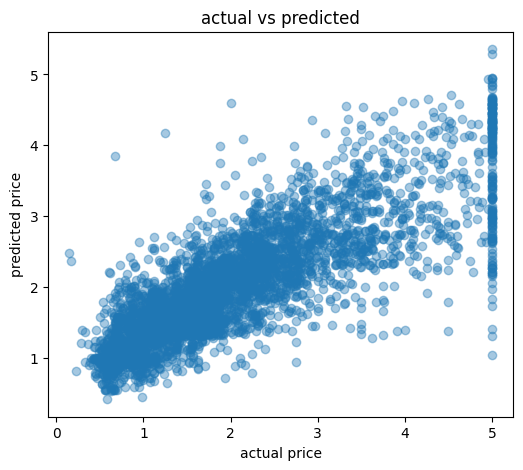

In [14]:
# 성능 시각화
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted")
plt.show()

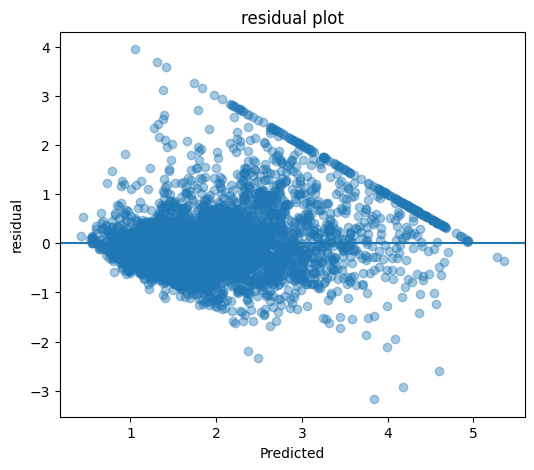

In [16]:
residuals = y_test-y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.4)

# 기준선(오차 0)
plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("residual")
plt.title("residual plot")

plt.show()

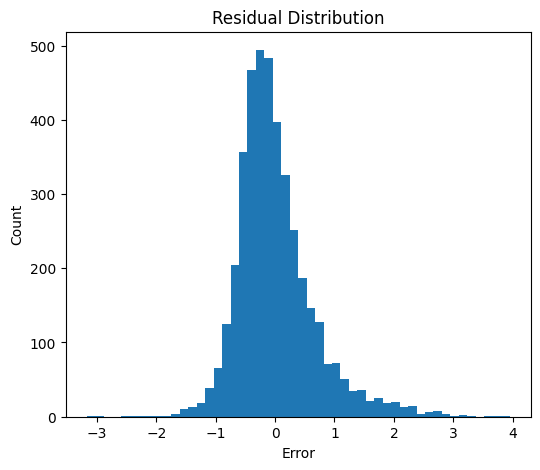

In [17]:
plt.figure(figsize=(6,5))

plt.hist(residuals, bins=50)
plt.xlabel("Error")
plt.ylabel("Count")

plt.title("Residual Distribution")

plt.show()

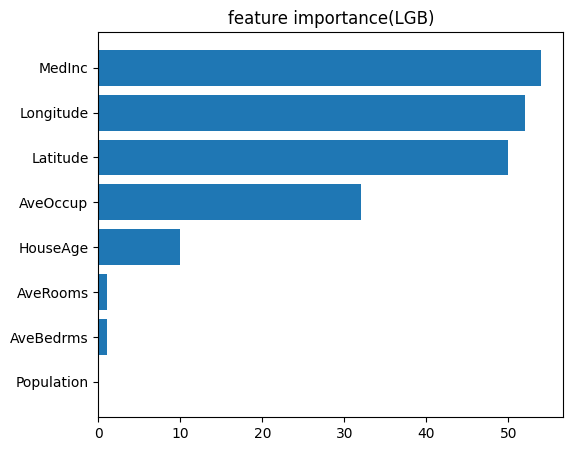

In [19]:
# feature importance
importance = model.feature_importances_

# 중요도 정렬
indices = np.argsort(importance)
plt.figure(figsize=(6,5))

# 가로 막대 그래프
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])

plt.title("feature importance(LGB)")
plt.show()

In [22]:
# 모델 예측
sample_data = X_test.iloc[:5]

# 예측 수행
sample_pred = model.predict(sample_data)

print("\n[샘플 예측 결과]")
for i, pred in enumerate(sample_pred):
    print(f"{i+1}번째 샘플 예측 집값: {pred:.4f}")


# 잘 예측 했는지 실제 값과 비교
print("\n[실제값]")
print(y_test.iloc[:5].values)


[샘플 예측 결과]
1번째 샘플 예측 집값: 0.9993
2번째 샘플 예측 집값: 1.4033
3번째 샘플 예측 집값: 3.0779
4번째 샘플 예측 집값: 2.7494
5번째 샘플 예측 집값: 2.2123

[실제값]
[0.477   0.458   5.00001 2.186   2.78   ]


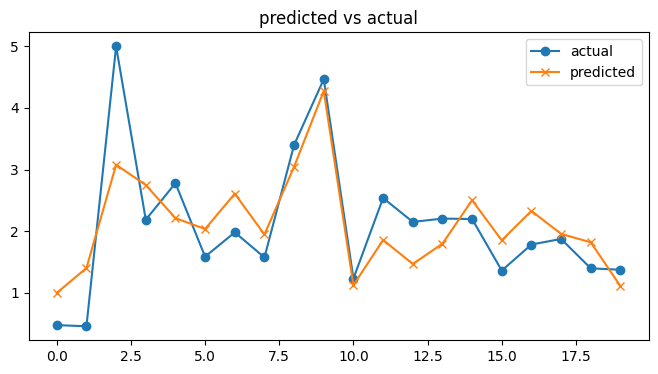

In [23]:
# 예측 결과 시각화
plt.figure(figsize=(8,4))
plt.plot(y_test.iloc[:20].values, label="actual", marker='o') # 실제값
plt.plot(model.predict(X_test.iloc[:20]), label="predicted", marker='x') # 예측값

plt.title("predicted vs actual")
plt.legend()
plt.show()